In [1]:
import pandas as pd

In [2]:
odd = pd.DataFrame({

    "weather": [
        "clear",
        "rain",
        "fog"
    ],

    "lighting": [
        "day",
        "night",
        "glare"
    ],

    "camera": [
        "clean",
        "dirty",
        "clean"
    ],

    "scene": [
        "urban",
        "highway",
        "urban"
    ],

    "speed": [
        "low",
        "high",
        "low"
    ]

})

print(odd)

  weather lighting camera    scene speed
0   clear      day  clean    urban   low
1    rain    night  dirty  highway  high
2     fog    glare  clean    urban   low


In [3]:
test_data = pd.DataFrame({

    "weather": ["clear"] * 3600,

    "lighting": ["day"] * 3600,

    "camera": ["clean"] * 3600,

    "scene": ["urban"] * 3600,

    "speed": ["low"] * 3600

})

In [4]:
import sys
import os

sys.path.append("../odd-coverage")

print(
    os.listdir(
        "../odd-coverage"
    )
)

['.git', 'kprojection.py', 'LICENSE', 'README.md']


In [5]:
import os

for root, dirs, files in os.walk("../odd-coverage"):
    for f in files:
        if f.endswith(".py"):
            print(root, f)

../odd-coverage kprojection.py


In [6]:
import sys

sys.path.append("../odd-coverage")

from kprojection import *

In [7]:
print([x for x in dir() if "proj" in x.lower()])

['KProjectionCoverage']


In [8]:
desc = {

    "weather": [
        "clear",
        "rain",
        "fog"
    ],

    "lighting": [
        "day",
        "night",
        "glare"
    ],

    "camera": [
        "clean",
        "dirty"
    ],

    "scene": [
        "urban",
        "highway"
    ],

    "speed": [
        "low",
        "high"
    ]

}

In [9]:
k1 = KProjectionCoverage(
    1,
    desc
)

k2 = KProjectionCoverage(
    2,
    desc
)

k3 = KProjectionCoverage(
    3,
    desc
)

In [10]:
print(dir(k1))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', 'add_scenario', 'add_scenarios', 'compute', 'desc', 'dim_value_to_index', 'dims', 'k', 'n_dim_values', 'n_dims', 'n_scenes', 'projections', 'reset', 'update']


In [11]:
k1.add_scenarios(
    test_data.to_dict(
        "records"
    )
)

k2.add_scenarios(
    test_data.to_dict(
        "records"
    )
)

k3.add_scenarios(
    test_data.to_dict(
        "records"
    )
)

In [12]:
# Computing the coverage here

k1_result = k1.compute()

k2_result = k2.compute()

k3_result = k3.compute()

print(
    "k=1:",
    k1_result
)

print(
    "k=2:",
    k2_result
)

print(
    "k=3:",
    k3_result
)

k=1: KCoverageResult(coverage=0.4166666666666667, k=1, covered=5, total=12, scenes=3600)
k=2: KCoverageResult(coverage=0.17543859649122806, k=2, covered=10, total=57, scenes=3600)
k=3: KCoverageResult(coverage=0.07462686567164178, k=3, covered=10, total=134, scenes=3600)


In [13]:
#documenting the above values
import pandas as pd

coverage_results = pd.DataFrame({

    "k": [
        k1_result.k,
        k2_result.k,
        k3_result.k
    ],

    "coverage": [
        k1_result.coverage,
        k2_result.coverage,
        k3_result.coverage
    ],

    "covered": [
        k1_result.covered,
        k2_result.covered,
        k3_result.covered
    ],

    "total": [
        k1_result.total,
        k2_result.total,
        k3_result.total
    ],

    "scenes": [
        k1_result.scenes,
        k2_result.scenes,
        k3_result.scenes
    ]

})

coverage_results.to_csv(
    "../results/excercise_4/k_projection_coverage.csv",
    index=False
)

print(
    "k_projection_coverage.csv saved successfully"
)

k_projection_coverage.csv saved successfully


In [14]:
#Excercise 3.7
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [16]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.df=dataframe

        self.image_dir=image_dir

        self.target=target

        self.transform=transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(self.df)


    def __getitem__(self,idx):

        row=self.df.iloc[idx]

        frame=row["frame"]

        filename=f"{frame:06d}.jpg"

        path=os.path.join(
            self.image_dir,
            filename
        )

        image=Image.open(path)

        image=self.transform(image)

        label=float(
            row[self.target]
        )

        return image,label

In [17]:
ped_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_pedestrian"
)

test_loader = DataLoader(
    ped_test,
    batch_size=64
)

In [18]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/pedestrian_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
# Start generating predictions here

predictions = []

true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

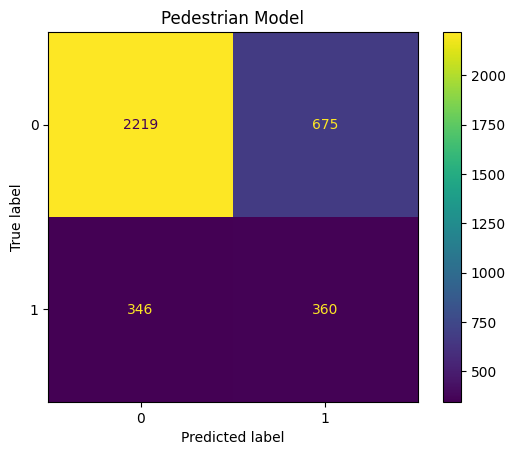

In [20]:
cm = confusion_matrix(
    true_labels,
    predictions
)

ped_confusion_matrix = cm

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Pedestrian Model"
)

plt.savefig(
    "../results/excercise_4/pedestrian_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [21]:
# Predictions and Confusion Matrix for Vehicle

vehicle_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_vehicle"
)

test_loader = DataLoader(
    vehicle_test,
    batch_size=64
)

model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/vehicle_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

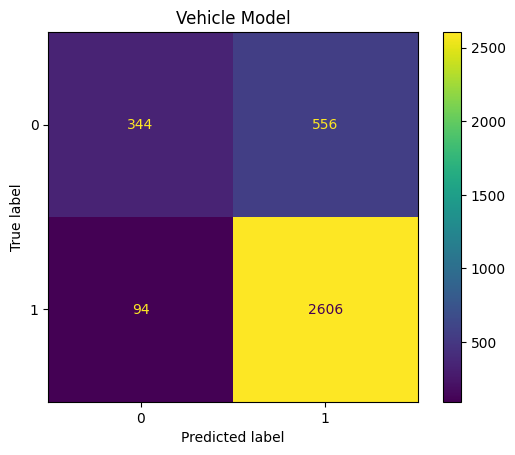

In [22]:
predictions = []

true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

cm = confusion_matrix(
    true_labels,
    predictions
)

vehicle_confusion_matrix = cm

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Vehicle Model"
)

plt.savefig(
    "../results/excercise_4/vehicle_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [23]:
traffic_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_traffic_light"
)

test_loader = DataLoader(
    traffic_test,
    batch_size=64
)

model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/traffic_light_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

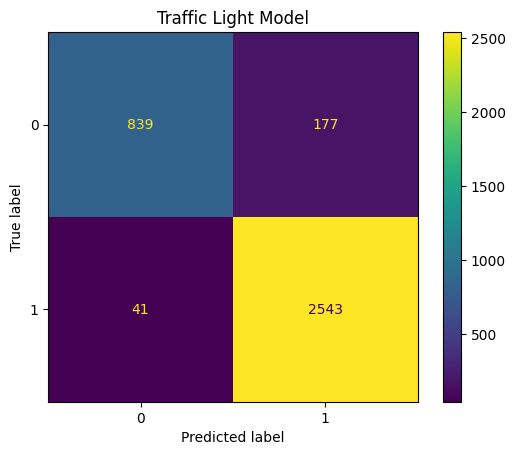

In [24]:
predictions = []

true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

cm = confusion_matrix(
    true_labels,
    predictions
)

traffic_confusion_matrix = cm

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Traffic Light Model"
)

plt.savefig(
    "../results/excercise_4/traffic_light_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [25]:
print("Pedestrian")
print(ped_confusion_matrix)

print("\nVehicle")
print(vehicle_confusion_matrix)

print("\nTraffic Light")
print(traffic_confusion_matrix)

Pedestrian
[[2219  675]
 [ 346  360]]

Vehicle
[[ 344  556]
 [  94 2606]]

Traffic Light
[[ 839  177]
 [  41 2543]]


In [26]:
#Generating the .csv file for excercise 4 results
import pandas as pd

rows = []

# K-Projection Coverage Results

rows.append(["K-PROJECTION COVERAGE", "", "", "", ""])
rows.append(["k", "coverage", "covered", "total", "scenes"])

rows.append([
    k1_result.k,
    k1_result.coverage,
    k1_result.covered,
    k1_result.total,
    k1_result.scenes
])

rows.append([
    k2_result.k,
    k2_result.coverage,
    k2_result.covered,
    k2_result.total,
    k2_result.scenes
])

rows.append([
    k3_result.k,
    k3_result.coverage,
    k3_result.covered,
    k3_result.total,
    k3_result.scenes
])

rows.append(["", "", "", "", ""])

# Pedestrian Confusion Matrix

rows.append(["PEDESTRIAN CONFUSION MATRIX", "", "", "", ""])
rows.append(["TN", "FP", "FN", "TP", ""])

rows.append([
    ped_confusion_matrix[0][0],
    ped_confusion_matrix[0][1],
    ped_confusion_matrix[1][0],
    ped_confusion_matrix[1][1],
    ""
])

rows.append(["", "", "", "", ""])

# Vehicle Confusion Matrix

rows.append(["VEHICLE CONFUSION MATRIX", "", "", "", ""])
rows.append(["TN", "FP", "FN", "TP", ""])

rows.append([
    vehicle_confusion_matrix[0][0],
    vehicle_confusion_matrix[0][1],
    vehicle_confusion_matrix[1][0],
    vehicle_confusion_matrix[1][1],
    ""
])

rows.append(["", "", "", "", ""])

# Traffic Light Confusion Matrix

rows.append(["TRAFFIC LIGHT CONFUSION MATRIX", "", "", "", ""])
rows.append(["TN", "FP", "FN", "TP", ""])

rows.append([
    traffic_confusion_matrix[0][0],
    traffic_confusion_matrix[0][1],
    traffic_confusion_matrix[1][0],
    traffic_confusion_matrix[1][1],
    ""
])

results_df = pd.DataFrame(rows)

results_df.to_csv(
    "../results/excercise_4/exercise4_results.csv",
    index=False,
    header=False
)

print(
    "exercise4_results.csv saved successfully"
)

exercise4_results.csv saved successfully
